# Test HYPE nitrogen model

In [46]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys, os
sys.path.append('../../src/nitrogen_model')
from nitrogen_model import *


## Explore functions

In [7]:
LABEL_FONTSIZE = 10
LINEWIDTH = 1

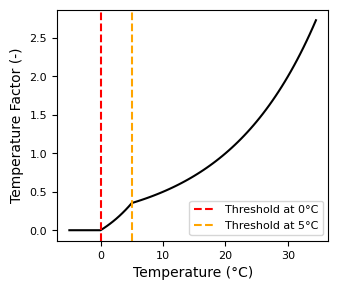

In [16]:
T = np.arange(-5, 35, 0.5) # Temperature range from -5°C to 35°C with 0.5°C increments
tempf = [tempfactor(temp) for temp in T]

fig, ax = plt.subplots(figsize=(3.5, 3))
sns.lineplot(x=T, y=tempf, color='black', ax=ax)
ax.set_xlabel('Temperature (°C)', fontsize = LABEL_FONTSIZE)
ax.set_ylabel('Temperature Factor (-)', fontsize = LABEL_FONTSIZE)
ax.axvline(x=0, color='red', linestyle='--', label='Threshold at 0°C')
ax.axvline(x=5, color='orange', linestyle='--', label='Threshold at 5°C')
ax.tick_params(axis='both', labelsize=LABEL_FONTSIZE-2)
ax.legend(fontsize=LABEL_FONTSIZE-2)


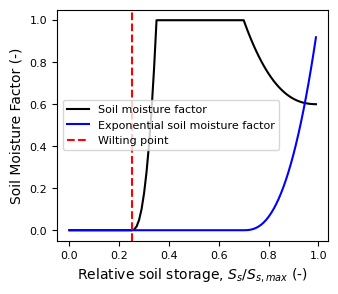

In [45]:
# Parameters for soil moisture factor
S_s_max = 1000
S_wp = S_s_max/4.0
smf_sat = 0.6
beta_smf = 1.0
rel_saturation_low = .1
rel_saturation_high = .3

S_s = np.arange(0, S_s_max, 10)
smf = [moisturefactor(S,S_wp, S_s_max,smf_sat,beta,rel_saturation_low,rel_saturation_high) for S in S_s] 

# Parameters for exponential soil moisture factor
limpar = 0.7
beta_expsmf = 2.5
exp_smf = [exponential_moisturefactor(S, S_s_max, limpar, beta_expsmf) for S in S_s]

fig, ax = plt.subplots(figsize=(3.5, 3))
sns.lineplot(x=S_s/S_s_max, y=smf, color='black', ax=ax, label='Soil moisture factor')
sns.lineplot(x=S_s/S_s_max, y=exp_smf, color='blue', ax=ax, label='Exponential soil moisture factor')
ax.set_xlabel('Relative soil storage, $S_s/S_{s,max}$ (-)', fontsize = LABEL_FONTSIZE)
ax.set_ylabel('Soil Moisture Factor (-)', fontsize = LABEL_FONTSIZE)
ax.axvline(x=S_wp/S_s_max, color='red', linestyle='--', label='Wilting point')
ax.tick_params(axis='both', labelsize=LABEL_FONTSIZE-2)
ax.legend(fontsize=LABEL_FONTSIZE-2)

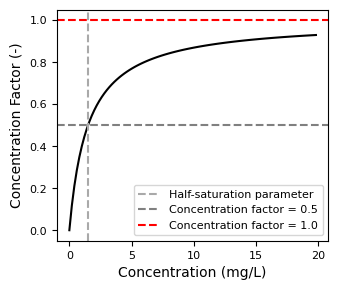

In [41]:
K = 1.5 # Half-saturation parameter (mg/L)      
c = np.arange(0, 20, .2)# Current concentration (mg/L)

concf = [concfactor(conc, K) for conc in c]

fig, ax = plt.subplots(figsize=(3.5, 3))
sns.lineplot(x=c, y=concf, color='black', ax=ax)
ax.set_xlabel('Concentration (mg/L)', fontsize = LABEL_FONTSIZE)
ax.set_ylabel('Concentration Factor (-)', fontsize = LABEL_FONTSIZE)
ax.axvline(x=K, color='darkgrey', linestyle='--', label='Half-saturation parameter')
ax.axhline(y=0.5, color='grey', linestyle='--', label='Concentration factor = 0.5')
ax.axhline(y=1.0, color='red', linestyle='--', label='Concentration factor = 1.0')
ax.tick_params(axis='both', labelsize=LABEL_FONTSIZE-2)
ax.legend(fontsize=LABEL_FONTSIZE-2)    

In [ ]:
params = {
    'S_wp': 20.0, # Wilting point storage (mm)
    'S_s_max': 100.0, # Maximum soil storage (mm) -- Assumed to equal the thickness of soil layer (m) (thickm in HYPE)
    'smf_sat': 0.8, # Saturated moisture factor (satact)
    'beta_sm': 1.0, # Exponent of moisture factor (thetapow)
    'rel_saturation_low': 0.2, # Low relative saturation (dimensionless, 0-1) -- This is (thetalow, %)/100
    'rel_saturation_high': 0.9, # High relative saturation (dimensionless, 0-1) -- This is (thetaupp, %)/100
    'rel_sat_limit_exp': 0.7, # Limitation parameter of moisture factor (dimensionless)
    'beta_exp': 2.5 # Exponent of exponential moisture factor
    'V_degrad_SON': 0.001, # Maximum degradation rate of soil slow organic nitrogen (1/day) -- This is the parameter degrhNpar in HYPE.
    'V_dissol_SON': 0.01, # Maximum dissolution rate of soil slow organic nitrogen (1/day) -- This is the parameter dissolhNpar in HYPE.
    'V_dissol_FON': 0.005, # Maximum dissolution rate of soil fast organic nitrogen (1/day) -- This is the parameter dissolfNpar in HYPE.
    'V_min_FON': 0.02 # Maximum mineralization rate of soil fast organic nitrogen (1/day) -- This is the parameter minfNpar in HYPE.
    'V_denit': 0.05, # Maximum denitrification rate (1/day)
    'K_denit': 1.5 # Half-saturation parameter (mg/L)
    'uptake_demand': 10.0, # Plant uptake demand (kg/km2/d) 
    'delta_time_solver': 1.0 # Time step (day)
}


## Test functions

In [ ]:
S_s_max = 1000
S_wp = S_s_max/4.0
smf_sat = 0.6
beta = 2.5
rel_saturation_low = .1
rel_saturation_high = .3

# Denitrification
V_denit = 0.05 # Maximum denitrification rate (1/day)
K_denit = 1.5 # Half-saturation parameter for denitrification (mg/L)
uptake_demand = 10.0 # Plant uptake demand (kg/km2/d)

V_degrad_SON = 0.001 # Maximum degradation rate of soil slow organic nitrogen (1/day)
V_dissol_SON = 0.01 # Maximum dissolution rate of soil slow organic nitrogen (1/day)
V_dissol_FON = 0.005 # Maximum dissolution rate of soil fast organic nitrogen (1/day)
V_min_FON = 0.02 # Maximum mineralization rate of soil fast organic nitrogen (1/day)
